##WorkSheet-5

##Task 1: Data Understanding and Visualization:

In [1]:
import zipfile

zip_path = "/content/FruitinAmazon.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [2]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
#Get Class Directories
train_dir = "/content/FruitinAmazon/train"

classes = os.listdir(train_dir)
print("Classes:", classes)

Classes: ['tucuma', 'pupunha', 'guarana', 'graviola', 'cupuacu', 'acai']


In [3]:
sample_images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    sample_images.append((cls, img_path))

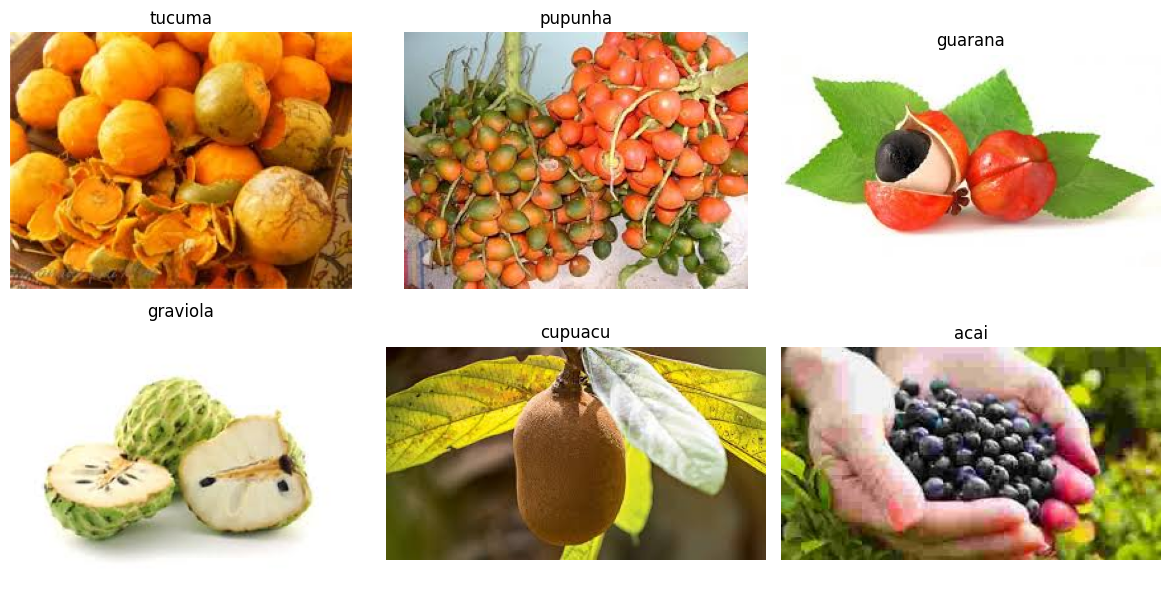

In [4]:
plt.figure(figsize=(12,6))

for i, (label, img_path) in enumerate(sample_images):

    img = Image.open(img_path)

    plt.subplot(2, len(sample_images)//2 + len(sample_images)%2, i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

Observation:
The dataset contains multiple fruit classes organized in folders. Each class contains images of a specific fruit with variations in background, lighting, and orientation. These variations make the dataset suitable for training a CNN model for image classification.

In [5]:
import os
from PIL import Image

train_dir = "/content/FruitinAmazon/train"

corrupted_images = []

# Iterate through each class folder
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)
                img.verify()  # verifies image integrity

            except (IOError, SyntaxError):
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

# Final output
if len(corrupted_images) == 0:
    print("No corrupted images found.")

No corrupted images found.


##Task 2: Loading and Preprocessing Image Data in keras:

In [7]:
# Task 2: Loading and Preprocessing Image Data in Keras

# 1. Import Required Library
import tensorflow as tf

# 2. Define Image Size and Batch Size
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# 3. Define Dataset Directory
train_dir = "/content/FruitinAmazon/train"

# 4. Create Normalization Layer
rescale = tf.keras.layers.Rescaling(1./255)

# 5. Load Training Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Save class names BEFORE mapping
class_names = train_ds.class_names

# 6. Apply Normalization to Training Dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# 7. Load Validation Dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# 8. Apply Normalization to Validation Dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# 9. Display Class Names
print("Class Names:", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Class Names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


##Task 3 - Implement a CNN with
Follow the following Structure and Hyper - parameters:

In [8]:
# Task 3: Implement CNN Model

from tensorflow.keras import layers, models

# Number of output classes
num_classes = len(class_names)

# Build CNN Model
model = models.Sequential([

    # Convolutional Layer 1
    layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu',
                  input_shape=(img_height, img_width, 3)),

    # Pooling Layer 1
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3,3), strides=1, padding='same', activation='relu'),

    # Pooling Layer 2
    layers.MaxPooling2D(pool_size=(2,2), strides=2),

    # Flatten Layer
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

##Task 4: Compile the Model

In [9]:
# Task 4: Compile and Train the CNN Model

import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 1. Compile the Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Callbacks (Save Best Model + Early Stopping)

# Save best model during training
checkpoint = ModelCheckpoint(
    "best_cnn_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Stop training early if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# 3. Train the Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.1701 - loss: 1.9071
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_cnn_model.h5



Epoch 1: finished saving model to best_cnn_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 536ms/step - accuracy: 0.1667 - loss: 1.9608 - val_accuracy: 0.1667 - val_loss: 1.7307
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.2905 - loss: 1.6653
Epoch 2: val_accuracy improved from 0.16667 to 0.77778, saving model to best_cnn_model.h5



Epoch 2: finished saving model to best_cnn_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 474ms/step - accuracy: 0.2778 - loss: 1.6690 - val_accuracy: 0.7778 - val_loss: 1.4426
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step - accuracy: 0.3438 - loss: 1.4834
Epoch 3: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 401ms/step - accuracy: 0.3750 - loss: 1.4625 - val_accuracy: 0.7222 - val_loss: 1.2218
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.4242 - loss: 1.2812
Epoch 4: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 397ms/step - accuracy: 0.4444 - loss: 1.2560 - val_accuracy: 0.6111 - val_loss: 1.0670
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.4740 - loss: 1.0955
Epoch 5: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 685ms/step - accuracy: 0.5000 - loss: 1.0924 - val_accuracy: 0.6667 - val_loss: 1.0573
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.7002 - loss: 0


Epoch 9: finished saving model to best_cnn_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 465ms/step - accuracy: 0.9306 - loss: 0.4243 - val_accuracy: 0.8333 - val_loss: 0.6729
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9398 - loss: 0.3278
Epoch 10: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 417ms/step - accuracy: 0.9444 - loss: 0.3252 - val_accuracy: 0.7778 - val_loss: 0.7770
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.9797 - loss: 0.2205
Epoch 11: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 390ms/step - accuracy: 0.9861 - loss: 0.2002 - val_accuracy: 0.8333 - val_loss: 0.8515
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - accuracy: 0.9902 - loss: 0.1328
Epoch 12: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 396ms/step - accuracy: 0.9861 - loss: 0.1306 - val_accuracy: 0.8333 - val_loss: 0.7063
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step - accuracy: 0.9502 - 


Epoch 17: finished saving model to best_cnn_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 438ms/step - accuracy: 0.9722 - loss: 0.0797 - val_accuracy: 0.8889 - val_loss: 0.5234
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step - accuracy: 1.0000 - loss: 0.0278
Epoch 18: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 414ms/step - accuracy: 1.0000 - loss: 0.0268 - val_accuracy: 0.6667 - val_loss: 0.9382
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.9797 - loss: 0.0341
Epoch 19: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 393ms/step - accuracy: 0.9861 - loss: 0.0296 - val_accuracy: 0.8333 - val_loss: 0.6877
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 1.0000 - loss: 0.0090
Epoch 20: val_accuracy did not improve from 0.88889
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 421ms/step - accuracy: 1.0000 - loss: 0.0109 - val_accuracy: 0.8333 - val_loss: 0.7044
Epoch 21/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 1.0000 -

##Task 5: Evaluate the Model

In [10]:
# evaluate model
test_loss, test_acc = model.evaluate(val_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.8889 - loss: 0.4319
Test Loss: 0.4319336712360382
Test Accuracy: 0.8888888955116272


##Task 6: Save and Load the Model

In [11]:
# save model
model.save("cnn_fruit_model.h5")

# load model
loaded_model = tf.keras.models.load_model("cnn_fruit_model.h5")

# evaluate loaded model
test_loss, test_acc = loaded_model.evaluate(val_ds)
print("Loaded Model Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.8889 - loss: 0.4319
Loaded Model Test Accuracy: 0.8888888955116272


##Task 7: Predictions and Classification Report

In [13]:
import numpy as np
from sklearn.metrics import classification_report

# get predictions for full dataset
y_pred = loaded_model.predict(val_ds)

# convert predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# collect true labels properly
y_true = np.concatenate([labels.numpy() for images, labels in val_ds], axis=0)

print(classification_report(
    y_true,
    y_pred_classes,
    labels=list(range(len(class_names))),
    target_names=class_names
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 488ms/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       1.00      0.67      0.80         3
      tucuma       0.93      0.93      0.93        15

    accuracy                           0.89        18
   macro avg       0.32      0.27      0.29        18
weighted avg       0.94      0.89      0.91        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me